# Matplotlib bar chart storytelling

In [2]:
import pandas as pd
import duckdb
from constants import GRAY_1, GRAY_2, GRAY_3, BLUE_1

df=pd.read_csv("data/norway_new_car_sales_by_make.csv")
df.head()

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5


In [9]:
df_quantity_brand = duckdb.query("""--sql
    SELECT make AS Brand, 
    SUM(Quantity) AS Quantity
    FROM df
    GROUP BY Brand                             
    ORDER BY Quantity 
    DESC
""").df().set_index("Brand")

df_quantity_brand

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0
...,...
McLaren,1.0
Martin Motors,1.0
Secma,1.0


## Bar charts

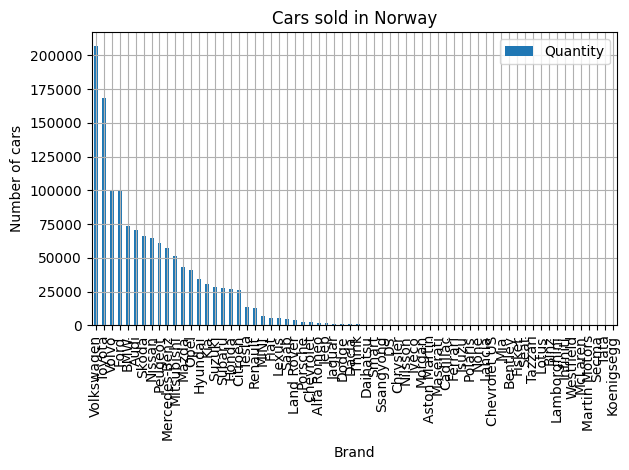

In [15]:
ax = df_quantity_brand.plot(kind="bar", title = "Cars sold in Norway", ylabel = "Number of cars")
ax.grid()
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("figures/0_bar_initial.png")

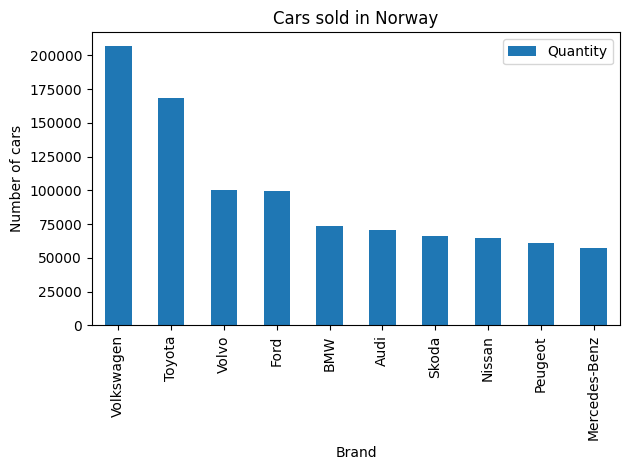

In [16]:
ax = df_quantity_brand.iloc[:10].plot(
    kind="bar", title = "Cars sold in Norway", ylabel = "Number of cars")

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("figures/1_bar_top10.png")

In [17]:
df_percentage = df_quantity_brand["Quantity"] / df_quantity_brand["Quantity"].sum() * 100
df_percentage

Brand
Volkswagen       15.340063
Toyota           12.482984
Volvo             7.417851
Ford              7.401225
BMW               5.441826
                   ...    
McLaren           0.000074
Martin Motors     0.000074
Secma             0.000074
Tata              0.000074
Koenigsegg        0.000074
Name: Quantity, Length: 66, dtype: float64

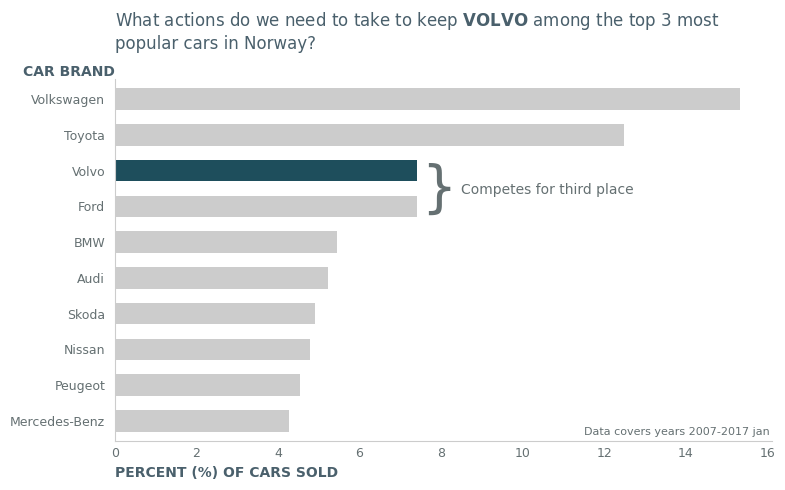

In [86]:
ax = df_percentage_top10.plot(
    kind="barh", ylabel = "Number of cars", figsize= (8,5), width=0.6, color = colors)
ax.invert_yaxis()

ax.set_title(
    "What actions do we need to take to keep " + r"$\bf{VOLVO}$" + " among the top 3 most \npopular cars in Norway?", 
    loc = "left",
    color = GRAY_3,
    pad= 22)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)
ax.tick_params(axis="both", colors = GRAY_2, labelsize= 9, length=0, pad = 5)
ax.tick_params(axis="y", pad = 7)

ax.set_ylabel("CAR BRAND", color = GRAY_3, fontweight = "bold", rotation = 0)
ax.yaxis.set_label_coords(-0.07,1)
ax.set_xlabel("PERCENT (%) OF CARS SOLD", color = GRAY_3, fontweight = "bold", loc = "left")

ax.annotate(xy =(7.5,2.95), text = "}", fontsize = 40, color = GRAY_2)
ax.annotate(xy =(8.5,2.65), text = "Competes for third place", fontsize = 10, color = GRAY_2)
ax.annotate(xy =(11.5,9.4), text = "Data covers years 2007-2017 jan", fontsize = 8, color = GRAY_2)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("figures/2_bar_storytelling.png", dpi=300)

In [39]:
df_percentage_top10 = df_percentage.iloc[:10]
colors = [GRAY_1]*len(df_percentage_top10)
colors[2]= BLUE_1
colors

['#CCCCCC',
 '#CCCCCC',
 '#1E4E5C',
 '#CCCCCC',
 '#CCCCCC',
 '#CCCCCC',
 '#CCCCCC',
 '#CCCCCC',
 '#CCCCCC',
 '#CCCCCC']